<div style="background-color: #F4F6F7; padding: 20px; border-radius: 8px; font-family: 'Arial', sans-serif; color: #2E4053;">
  <!-- Logo centrado -->
  <div style="text-align: center; margin-bottom: 15px;">
    <img src="https://drive.google.com/uc?export=view&id=1kjzXfjTiieYAd4azw5bh4UfEg91gUIdh" alt="Logo Institucional" width="250" />
  </div>

  <!-- Título principal -->
  <h1 style="font-size: 36px; font-weight: bold; text-align: right;">
    <strong>Estimación del gradiente geotérmico a partir de imágenes multiespectrales del LANDSAT 7 y base de datos tabular</strong>
  </h1>

  <!-- Datos del estudiante -->
  <p style="font-size: 22px; text-align: center; margin: 5px 0;">
    <strong>Nombre:</strong> Carlos Enrique Montilla Morales &nbsp;|&nbsp;
    <strong>Institución:</strong> Universidad Tecnológica de Pereira  &nbsp;|&nbsp;
    <strong>Grupo de investigación en Automática </strong>
  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />

  <!-- Descripción breve -->
  <p style="font-size: 18px; text-align: center; font-style: italic; margin: 5px 0;">
    Este cuaderno es la primera prueba donde se entrena un modelo multimodal mediante el uso de imágenes satelitales multiespectrales del LANDSAT7 y una base de datos que contienen diversas variables geológicas y geofísicas para estimar el gradiente geotérmico en Colombia. Incluye: ingestión y preprocesado de mosaicos (manejo de NoData), creación de muestras/parches, estrategia de fine-tuning, evaluación con métricas de regresión R2, MAE y RMSE y exportación de predicciones y checkpoints para análisis geoespacial.

  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />
</div>


# **1. Carga de las librerías, imágenes y la base de datos**

In [ ]:
!pip install -q --upgrade pip
!pip install -q rasterio==1.4 pyproj rioxarray
!pip install -q torchvision tqdm scikit-image pandas
!pip install torch-optimizer
import warnings
warnings.filterwarnings(
    "ignore",
    message="This overload of addcmul_ is deprecated"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torch-optimizer]


In [ ]:
#!gdown 1jxJkZG92IpRO8GWkLS3C3u_zk0ILLb45 # Base de datos Min-Max
!gdown 1OIJY8QtxRYr4HW504Awxama22OAuBJID # Base de datos cruda
#!gdown 1nytEFrec9pQHrT4_0eT4gqocS6FJBrPq # Base de datos reducida
#!gdown 1gNupu09mzDMq_GLrCJg2Au9UVUMsMCIQ #Base de datos cruda con pesos
#!gdown 1BAm52wXxOT0DeZBbgv9FgDrVCfMFrUF_ #Geotiffs
#!gdown 1oZAsFy_yDXnJUbUQbuIMlIS-SFaEhd_X #Geotiffs completos
!gdown 1CnCNvGQSoWNEIbNz-j5bIa_COHpK15-l #Geotiffs completos 256

!unzip -q LANDSAT_GEOTIFF_COMPLETE_256.zip -d LANDSAT_GEOTIFF
#!unzip -q LANDSAT_GEOTIFF.zip -d LANDSAT_GEOTIFF

Downloading...
From: https://drive.google.com/uc?id=1OIJY8QtxRYr4HW504Awxama22OAuBJID
To: /content/data_prep.csv
100% 1.01M/1.01M [00:00<00:00, 13.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1CnCNvGQSoWNEIbNz-j5bIa_COHpK15-l
From (redirected): https://drive.google.com/uc?id=1CnCNvGQSoWNEIbNz-j5bIa_COHpK15-l&confirm=t&uuid=a64c27ed-9e34-4fef-8c2c-19878bc9597d
To: /content/LANDSAT_GEOTIFF_COMPLETE_256.zip
100% 4.26G/4.26G [00:51<00:00, 82.5MB/s]


In [ ]:
import os, re, time, joblib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

import rasterio
from scipy.spatial import cKDTree
from skimage.transform import resize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch_optimizer as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torchvision.models as models
import geopandas as gpd

BASE_DIR = Path("/content/LANDSAT_GEOTIFF/LANDSAT_GEOTIFF")
CSV_BASE = Path("/content/data_prep.csv")
#CSV_BASE = Path("/content/normalized_data_multimodal2.csv")
TARGET_COL = "Apparent Geothermal Gradient (°C/Km)"
OUT_DIR = Path("/content/run_resnet50_attention")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------

TARGET_SIZE = (256,256)
FILL_METHOD_IMAGE = 'knn'
K_NEIGHBORS = 8
IMAGE_NORM = 'zscore'
TAB_IMPUTE_METHOD = 'knn'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
NUM_WORKERS = 2

EPOCHS_HEAD = 4
EPOCHS_BACKBONE = 4
EPOCHS_FULL = 4
LR_HEAD = 1e-4
LR_FINE = 1e-5
LR_FULL = 1e-6
WEIGHT_DECAY = 1e-3

print("Device:", DEVICE)


Device: cuda


In [ ]:
# Cell 2
dataframe = pd.read_csv(CSV_BASE,delimiter = ";")
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4543 entries, 0 to 4542
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Latitude                              4543 non-null   float64
 1   Longitude                             4543 non-null   float64
 2   Elevation (m)                         4543 non-null   float64
 3   Surface Temperature (°C)              4543 non-null   float64
 4   Apparent Geothermal Gradient (°C/Km)  4543 non-null   float64
 5   Moho Depth (m)                        4543 non-null   float64
 6   Magnetic Anomaly (nT)                 4543 non-null   float64
 7   Fault                                 4543 non-null   float64
 8   Strike-slip Fault                     4543 non-null   float64
 9   Reverse or Thrust Fault               4543 non-null   float64
 10  Lineament                             4543 non-null   float64
 11  Right-lateral Fau

In [ ]:
# Cell 3

corr = dataframe.corr()
corr.style.background_gradient(cmap='coolwarm')

,Latitude,Longitude,Moho Depth (m),Strike-slip Fault,Reverse or Thrust Fault,Right-lateral Fault,Nearest Basement,Normal Fault,Active Fault,Magnetic Anomaly (nT),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),ID,Apparent Geothermal Gradient (°C/Km)
Latitude,1.000000,0.452054,-0.271407,-0.090198,-0.049055,-0.140780,-0.061779,-0.283835,0.118403,0.371312,-0.124358,0.261573,0.038218,-0.291491
Longitude,0.452054,1.000000,-0.444118,0.592673,0.532238,0.564063,0.625135,-0.125900,0.367347,-0.083259,0.170925,0.364975,-0.003839,0.111242
Moho Depth (m),-0.271407,-0.444118,1.000000,-0.556485,-0.498320,-0.439529,-0.565745,-0.474173,-0.281106,0.185697,-0.681505,-0.894115,-0.184117,-0.253195
Strike-slip Fault,-0.090198,0.592673,-0.556485,1.000000,0.848337,0.805541,0.818083,0.286289,0.465330,-0.364356,0.534042,0.548969,0.039104,0.429858
Reverse or Thrust Fault,-0.049055,0.532238,-0.498320,0.848337,1.000000,0.867953,0.812442,0.126355,0.599448,-0.267033,0.471181,0.563996,-0.006848,0.344768
Right-lateral Fault,-0.140780,0.564063,-0.439529,0.805541,0.867953,1.000000,0.825255,0.184544,0.619492,-0.311222,0.403514,0.439264,0.026146,0.350043
Nearest Basement,-0.061779,0.625135,-0.565745,0.818083,0.812442,0.825255,1.000000,0.335462,0.573878,-0.441166,0.581577,0.564282,-0.050195,0.357515
Normal Fault,-0.283835,-0.125900,-0.474173,0.286289,0.126355,0.184544,0.335462,1.000000,0.186161,-0.496615,0.632367,0.404851,0.213910,0.319285
Active Fault,0.118403,0.367347,-0.281106,0.465330,0.599448,0.619492,0.573878,0.186161,1.000000,-0.248765,0.270670,0.351065,-0.138178,0.126403
Magnetic Anomaly (nT),0.371312,-0.083259,0.185697,-0.364356,-0.267033,-0.311222,-0.441166,-0.496615,-0.248765,1.000000,-0.364603,-0.109004,0.154323,-0.221163


In [ ]:
# Cell 4

def read_geotiff(path: Path):
    with rasterio.open(str(path)) as ds:
        arr = ds.read().astype(float)
        nodata = ds.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        return arr, ds.meta

def fill_missing_median(arr):
    out = arr.copy()
    for b in range(out.shape[0]):
        band = out[b]
        mask = np.isnan(band)
        if mask.any():
            med = np.nanmedian(band)
            band[mask] = med if not np.isnan(med) else 0.0
        out[b] = band
    return out

def fill_missing_knn_mean(arr, k=10):
    out = arr.copy()
    for b in range(out.shape[0]):
        band = out[b]
        nan = np.isnan(band)
        if not nan.any():
            continue
        ys, xs = np.where(~nan)
        if len(ys) == 0:
            band[nan] = 0.0
            continue
        tree = cKDTree(np.c_[ys, xs])
        ys_n, xs_n = np.where(nan)
        _, idx = tree.query(np.c_[ys_n, xs_n], k=min(k, len(ys)))
        band[ys_n, xs_n] = band[ys[idx], xs[idx]].mean(axis=1)
    return out

def resize_multiband(arr, target_size=TARGET_SIZE):
    bands, H, W = arr.shape
    Ht, Wt = target_size

    if (H, W) == (Ht, Wt):
        return arr

    else:
        arr_t = np.transpose(arr, (1,2,0))
        resized = resize(
            arr_t, (Ht, Wt, bands),
            order=1,
            preserve_range=True,
            anti_aliasing=True
        )
        return np.transpose(resized, (2,0,1))

def normalize_image_minmax(arr):
    out = arr.astype(np.float32)
    for b in range(out.shape[0]):
        mn, mx = np.nanmin(out[b]), np.nanmax(out[b])
        out[b] = (out[b] - mn) / (mx - mn + 1e-8)
    return out

In [ ]:
# Cell 5

df_base = pd.read_csv(CSV_BASE, delimiter=';')
df_base = df_base[['Latitude', 'Longitude', 'Moho Depth (m)',
       'Strike-slip Fault', 'Reverse or Thrust Fault',
       'Right-lateral Fault', 'Nearest Basement',
       'Normal Fault', 'Active Fault','Magnetic Anomaly (nT)',
        'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)', 'ID', 'Apparent Geothermal Gradient (°C/Km)']]
df = df_base.copy()
df['ID'] = df['ID'].astype(str).str.extract(r'(\d+)').astype(int)
df['tif_name'] = df['ID'].apply(lambda x: f"LANDSAT7_{x}.tif")
df = df[df['tif_name'].apply(lambda x: (BASE_DIR/x).exists())].reset_index(drop=True)

FINAL_CSV = OUT_DIR / "final_dataset.csv"
df.to_csv(FINAL_CSV, index=False)
print("CSV final:", FINAL_CSV)

CSV final: /content/run_resnet50_attention/final_dataset.csv


In [ ]:
# Cell 6

# Cargar datos
df_final = pd.read_csv(FINAL_CSV)

# Columnas a excluir explícitamente
drop_cols = ['ID', TARGET_COL, 'tif_name']
drop_cols = [c for c in drop_cols if c in df_final.columns]

# Columnas que no se deben escalar
NO_SCALE_COLS = ['Volcanic domain', 'Volcanic weight', 'Longitude', 'Latitude']
NO_SCALE_COLS = [c for c in NO_SCALE_COLS if c in df_final.columns]

# Forzar todo a numérico
for c in df_final.columns:
    if c not in drop_cols:
        df_final[c] = pd.to_numeric(df_final[c], errors='coerce')

# Seleccionar solo columnas numéricas válidas
tabular_cols = [
    c for c in df_final.columns
    if c not in drop_cols
    and pd.api.types.is_numeric_dtype(df_final[c])
    and not df_final[c].isna().all()
]

# Columnas que si se escalan
scale_cols = [c for c in tabular_cols if c not in NO_SCALE_COLS]

print("Columnas tabulares:", tabular_cols)
print("Columnas escaladas:", scale_cols)
print("Columnas NO escaladas:", NO_SCALE_COLS)

# Eliminar filas con NaN en tabulares o target
df_final = df_final.dropna(
    subset=tabular_cols + [TARGET_COL]
).reset_index(drop=True)

print("Registros tras eliminar NaNs:", len(df_final))

# Split train / test
train_df, test_df = train_test_split(
    df_final, test_size=0.2, random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# StandatSCALER
scaler_tab = StandardScaler()

train_df[scale_cols] = scaler_tab.fit_transform(train_df[scale_cols])
test_df[scale_cols]  = scaler_tab.transform(test_df[scale_cols])

joblib.dump(scaler_tab, OUT_DIR / "tabular_scaler.pkl")

# TRANSFORMACIÓN TARGET: log1p + StandarScaler

# Guardar versión original
train_df[TARGET_COL + "_raw"] = train_df[TARGET_COL].copy()
test_df[TARGET_COL + "_raw"]  = test_df[TARGET_COL].copy()

# Manejo de negativos antes de log
min_train_target = train_df[TARGET_COL].min()
target_shift = 0.0

if min_train_target <= -1:
    target_shift = float(abs(min_train_target) + 1.0)
    print(f"Aplicando shift al target: {target_shift:.6f}")
    train_df[TARGET_COL] += target_shift
    test_df[TARGET_COL]  += target_shift

# Log-transform
train_df[TARGET_COL] = np.log1p(train_df[TARGET_COL].astype(float))
test_df[TARGET_COL]  = np.log1p(test_df[TARGET_COL].astype(float))

# StandardScaler target
scaler_y = StandardScaler()
train_df[[TARGET_COL]] = scaler_y.fit_transform(train_df[[TARGET_COL]])
test_df[[TARGET_COL]]  = scaler_y.transform(test_df[[TARGET_COL]])

joblib.dump(scaler_y, OUT_DIR / "target_scaler.pkl")
joblib.dump({"shift": target_shift}, OUT_DIR / "target_shift.json")

Columnas tabulares: ['Latitude', 'Longitude', 'Moho Depth (m)', 'Strike-slip Fault', 'Reverse or Thrust Fault', 'Right-lateral Fault', 'Nearest Basement', 'Normal Fault', 'Active Fault', 'Magnetic Anomaly (nT)', 'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)']
Columnas escaladas: ['Moho Depth (m)', 'Strike-slip Fault', 'Reverse or Thrust Fault', 'Right-lateral Fault', 'Nearest Basement', 'Normal Fault', 'Active Fault', 'Magnetic Anomaly (nT)', 'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)']
Columnas NO escaladas: ['Longitude', 'Latitude']
Registros tras eliminar NaNs: 4543
✔ Pipeline completado: StandarScaler + log1p en target


In [ ]:
# Cell 7

class MultimodalDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        arr, _ = read_geotiff(BASE_DIR / f"LANDSAT7_{row.ID}.tif")
        arr = fill_missing_median(arr)
        arr = resize_multiband(arr, TARGET_SIZE)
        arr = normalize_image_minmax(arr)
        img = torch.from_numpy(arr.astype(np.float32))

        tab_vals = row[tabular_cols].to_numpy(dtype=np.float32, copy=True)
        tab = torch.from_numpy(tab_vals)

        y = torch.tensor(np.float32(row[TARGET_COL]), dtype=torch.float32)

        return {
            "image": img,
            "tabular": tab,
            "target": y,
            "id": int(row.ID)
        }

In [ ]:
# Cell 8

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        attn = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * attn


class MultiQueryCrossAttention(nn.Module):
    def __init__(self, img_dim, tab_dim, n_queries=8, heads=4, dropout=0.25):
        super().__init__()
        self.n_queries = n_queries
        self.img_dim = img_dim

        # Queries aprendibles
        self.query_base = nn.Parameter(
            torch.randn(1, n_queries, img_dim)
        )

        # Modulación por tabular
        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, img_dim),
            nn.ReLU()
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=img_dim,
            num_heads=heads,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, img_tokens, tab):
        B = tab.size(0)

        q = self.query_base.expand(B, -1, -1)

        tab_embed = self.tab_proj(tab).unsqueeze(1)
        q = q + tab_embed
        q = self.dropout(q)

        out, attn_weights = self.attn(
            query=q,
            key=img_tokens,
            value=img_tokens
        )

        out = out.mean(dim=1)

        return out

In [ ]:
# Cell 9

class Resnet50_Attention(nn.Module):
    def __init__(self, in_channels, n_tabular):
        super().__init__()

        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )

        if in_channels != 3:
            resnet.conv1 = nn.Conv2d(
                in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
            )

        # Backbone por bloques
        self.stem = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool
        )
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2  # 512
        self.layer3 = resnet.layer3  # 1024
        self.layer4 = resnet.layer4  # 2048

        # Spatial attention
        self.spatial_attn = SpatialAttention()

        # FPN-lite alinear canales
        self.fpn = nn.ModuleList([
            nn.Conv2d(512, 256, 1),
            nn.Conv2d(1024, 256, 1),
            nn.Conv2d(2048, 256, 1),
        ])

        # Tabular
        self.tab_fc = nn.Sequential(
            nn.Linear(n_tabular, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        # Cross attention
        self.cross_attn = MultiQueryCrossAttention(
            img_dim=256,
            tab_dim=128,
            n_queries=8,
            heads=4,
            dropout=0.25
        )

        #Head
        self.head = nn.Sequential(
            nn.Linear(256 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, img, tab):
        # Backbone
        x = self.stem(img)
        x = self.layer1(x)
        f2 = self.layer2(x)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)

        # Spatial attention
        f2 = self.spatial_attn(f2)
        f3 = self.spatial_attn(f3)
        f4 = self.spatial_attn(f4)

        # Tabular
        t = self.tab_fc(tab)

        # Cross-attention por escala
        fused = []
        for f, conv in zip([f2, f3, f4], self.fpn):
            f = conv(f)                     # (B,256,H,W)
            B, C, H, W = f.shape
            tokens = f.flatten(2).transpose(1, 2)  # (B,HW,256)
            z = self.cross_attn(tokens, t) # (B,256)
            fused.append(z)

        # Fusion multi-scale
        z = torch.cat(fused, dim=1)

        return self.head(z).squeeze(1)

In [ ]:
# Cell 10

train_loader = DataLoader(MultimodalDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(MultimodalDataset(test_df), batch_size=BATCH_SIZE)

model = Resnet50_Attention(
    in_channels=train_loader.dataset[0]["image"].shape[0],
    n_tabular=len(tabular_cols)
).to(DEVICE)

#optimizer = torch.optim.AdamW(model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
#optimizer = optim.Ranger(model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.SmoothL1Loss(beta=0.5)


#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
# Cell 11: entrenar cabeza

best_test_rmse = np.inf

for ep in range(1, EPOCHS_HEAD+1):
    # Entrenamiento
    model.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f"Head Epoch {ep}", leave=False)
    for batch in pbar:
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()
        targets = batch['target'].to(DEVICE).float()

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})
    scheduler.step(np.mean(train_losses))


    # Métricas
    model.eval()
    train_preds = []
    train_targs = []
    with torch.no_grad():
        for batch in train_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            train_preds.append(preds.cpu().numpy())
            train_targs.append(targets.cpu().numpy())

    if len(train_preds) > 0:
        train_preds_arr = np.concatenate(train_preds)
        train_targs_arr = np.concatenate(train_targs)
        tr_rmse = np.sqrt(np.mean((train_targs_arr - train_preds_arr)**2))
        tr_mae  = mean_absolute_error(train_targs_arr, train_preds_arr)
        try:
            tr_r2 = r2_score(train_targs_arr, train_preds_arr)
        except Exception:
            tr_r2 = float('nan')
    else:
        tr_rmse = tr_mae = tr_r2 = float('nan')

    print(f"[Head] Epoch {ep}/{EPOCHS_HEAD}  TrainLoss={np.mean(train_losses):.4f}  TrainRMSE={tr_rmse:.4f}  TrainMAE={tr_mae:.4f}  TrainR2={tr_r2:.4f}")

    #Métricas sobre test
    preds_list, targs_list = [], []
    ids_list = []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            preds_list.append(preds.cpu().numpy())
            targs_list.append(targets.cpu().numpy())
            ids_list.extend(batch['id'])

    if len(preds_list) > 0:
        preds_arr = np.concatenate(preds_list)
        targs_arr = np.concatenate(targs_list)
        test_rmse = np.sqrt(np.mean((targs_arr - preds_arr)**2))
        test_mae  = mean_absolute_error(targs_arr, preds_arr)
        try:
            test_r2 = r2_score(targs_arr, preds_arr)
        except Exception:
            test_r2 = float('nan')
    else:
        test_rmse = test_mae = test_r2 = float('nan')

    print(f"       TestRMSE={test_rmse:.4f}  TestMAE={test_mae:.4f}  TestR2={test_r2:.4f}")

    # Guardar mejor según test
    if test_rmse < best_test_rmse - 1e-6:
        best_test_rmse = test_rmse
        torch.save({"epoch": ep, "model": model.state_dict(), "opt": optimizer.state_dict()}, OUT_DIR / "best_head.pth")
        print("  -> Mejor modelo (head) guardado.")

[Head] Epoch 1/4  TrainLoss=0.5000  TrainRMSE=0.9012  TrainMAE=0.6423  TrainR2=0.1878
       TestRMSE=0.9674  TestMAE=0.6726  TestR2=0.1348
  -> Mejor modelo (head) guardado.


[Head] Epoch 2/4  TrainLoss=0.4295  TrainRMSE=0.8210  TrainMAE=0.5767  TrainR2=0.3260
       TestRMSE=0.8955  TestMAE=0.6182  TestR2=0.2586
  -> Mejor modelo (head) guardado.


[Head] Epoch 3/4  TrainLoss=0.3914  TrainRMSE=0.7898  TrainMAE=0.5524  TrainR2=0.3762
       TestRMSE=0.8616  TestMAE=0.5869  TestR2=0.3137
  -> Mejor modelo (head) guardado.


[Head] Epoch 4/4  TrainLoss=0.3653  TrainRMSE=0.7708  TrainMAE=0.5204  TrainR2=0.4059
       TestRMSE=0.8562  TestMAE=0.5653  TestR2=0.3223
  -> Mejor modelo (head) guardado.


In [ ]:
# Cell 12: unfreeze backbone

ck = torch.load(OUT_DIR / "best_head.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
print("Cargado checkpoint head")

# Congelar todo primero
for p in model.parameters():
    p.requires_grad = False

# Descongelar solo capas profundas del backbone
for m in [model.layer3, model.layer4]:
    for p in m.parameters():
        p.requires_grad = True

# Dejar entrenables módulos de fusión y head
for m in [model.fpn, model.cross_attn, model.tab_fc, model.head]:
    for p in m.parameters():
        p.requires_grad = True


#optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINE, weight_decay=WEIGHT_DECAY)
#optimizer = optim.Ranger(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINE, weight_decay=WEIGHT_DECAY)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_FINE,
    weight_decay=WEIGHT_DECAY
)

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


best_test_rmse_backbone = best_test_rmse  # Viene de la fase head

for ep in range(1, EPOCHS_BACKBONE+1):
    model.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f"Backbone Epoch {ep}", leave=False)
    for batch in pbar:
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()
        targets = batch['target'].to(DEVICE).float()

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})
    scheduler.step(np.mean(train_losses))

    # Métricas por train
    model.eval()
    train_preds = []
    train_targs = []
    with torch.no_grad():
        for batch in train_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            train_preds.append(preds.cpu().numpy())
            train_targs.append(targets.cpu().numpy())

    if len(train_preds) > 0:
        train_preds_arr = np.concatenate(train_preds)
        train_targs_arr = np.concatenate(train_targs)
        tr_rmse = np.sqrt(np.mean((train_targs_arr - train_preds_arr)**2))
        tr_mae  = mean_absolute_error(train_targs_arr, train_preds_arr)
        try:
            tr_r2 = r2_score(train_targs_arr, train_preds_arr)
        except Exception:
            tr_r2 = float('nan')
    else:
        tr_rmse = tr_mae = tr_r2 = float('nan')

    print(f"[Backbone] Epoch {ep}/{EPOCHS_BACKBONE}  TrainLoss={np.mean(train_losses):.4f}  "
          f"TrainRMSE={tr_rmse:.4f}  TrainMAE={tr_mae:.4f}  TrainR2={tr_r2:.4f}")

    # Métricas por test
    preds_list, targs_list = [], []
    ids_list = []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            preds_list.append(preds.cpu().numpy())
            targs_list.append(targets.cpu().numpy())
            ids_list.extend(batch['id'])

    if len(preds_list) > 0:
        preds_arr = np.concatenate(preds_list)
        targs_arr = np.concatenate(targs_list)
        test_rmse = np.sqrt(np.mean((targs_arr - preds_arr)**2))
        test_mae  = mean_absolute_error(targs_arr, preds_arr)
        try:
            test_r2 = r2_score(targs_arr, preds_arr)
        except Exception:
            test_r2 = float('nan')
    else:
        test_rmse = test_mae = test_r2 = float('nan')

    print(f"         TestRMSE={test_rmse:.4f}  TestMAE={test_mae:.4f}  TestR2={test_r2:.4f}")

    # Guardar el mejor por test
    if test_rmse < best_test_rmse_backbone - 1e-6:
        best_test_rmse_backbone = test_rmse
        torch.save({"epoch": ep, "model": model.state_dict(), "opt": optimizer.state_dict()}, OUT_DIR / "best_backbone.pth")
        print("  -> Mejor modelo (backbone) guardado.")

Cargado checkpoint head


[Backbone] Epoch 1/4  TrainLoss=0.3352  TrainRMSE=0.7411  TrainMAE=0.4964  TrainR2=0.4508
         TestRMSE=0.8412  TestMAE=0.5524  TestR2=0.3458
  -> Mejor modelo (backbone) guardado.


[Backbone] Epoch 2/4  TrainLoss=0.3254  TrainRMSE=0.7274  TrainMAE=0.4894  TrainR2=0.4709
         TestRMSE=0.8348  TestMAE=0.5503  TestR2=0.3557
  -> Mejor modelo (backbone) guardado.


[Backbone] Epoch 3/4  TrainLoss=0.3205  TrainRMSE=0.7177  TrainMAE=0.4814  TrainR2=0.4848
         TestRMSE=0.8351  TestMAE=0.5510  TestR2=0.3553


[Backbone] Epoch 4/4  TrainLoss=0.3109  TrainRMSE=0.7092  TrainMAE=0.4718  TrainR2=0.4970
         TestRMSE=0.8378  TestMAE=0.5500  TestR2=0.3510


In [ ]:
# Cell 13: fine-tuning full

# Cargar mejor checkpoint previo (backbone o head)
ck_path = None
for p in ["best_backbone.pth", "best_head.pth"]:
    if (OUT_DIR / p).exists():
        ck_path = OUT_DIR / p
        break
if ck_path is None:
    raise FileNotFoundError("No se encontró checkpoint para arrancar full fine-tune final.")
ck = torch.load(OUT_DIR / ck_path.name, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
print("Loaded checkpoint for final fine-tune:", ck_path)

# Desbloquear todos los parámetros para fine-tune completo
for param in model.parameters():
    param.requires_grad = True

#optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
#optimizer = optim.Ranger(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_FULL,
    weight_decay=WEIGHT_DECAY
)

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


best_test_rmse_full = np.inf

for ep in range(1, EPOCHS_FULL+1):
    model.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f"Full Epoch {ep}", leave=False)
    for batch in pbar:
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()
        targets = batch['target'].to(DEVICE).float()

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})
    scheduler.step(np.mean(train_losses))

    model.eval()
    train_preds = []
    train_targs = []
    with torch.no_grad():
        for batch in train_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            train_preds.append(preds.cpu().numpy())
            train_targs.append(targets.cpu().numpy())

    if len(train_preds) > 0:
        train_preds_arr = np.concatenate(train_preds)
        train_targs_arr = np.concatenate(train_targs)
        tr_rmse = np.sqrt(np.mean((train_targs_arr - train_preds_arr)**2))
        tr_mae  = mean_absolute_error(train_targs_arr, train_preds_arr)
        try:
            tr_r2 = r2_score(train_targs_arr, train_preds_arr)
        except Exception:
            tr_r2 = float('nan')
    else:
        tr_rmse = tr_mae = tr_r2 = float('nan')

    print(f"[Full] Epoch {ep}/{EPOCHS_FULL}  TrainLoss={np.mean(train_losses):.4f}  "
          f"TrainRMSE={tr_rmse:.4f}  TrainMAE={tr_mae:.4f}  TrainR2={tr_r2:.4f}")

    preds_list, targs_list = [], []
    ids_list = []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            preds_list.append(preds.cpu().numpy())
            targs_list.append(targets.cpu().numpy())
            ids_list.extend(batch['id'])

    if len(preds_list) > 0:
        preds_arr = np.concatenate(preds_list)
        targs_arr = np.concatenate(targs_list)
        test_rmse = np.sqrt(np.mean((targs_arr - preds_arr)**2))
        test_mae  = mean_absolute_error(targs_arr, preds_arr)
        try:
            test_r2 = r2_score(targs_arr, preds_arr)
        except Exception:
            test_r2 = float('nan')
    else:
        test_rmse = test_mae = test_r2 = float('nan')

    print(f"         TestRMSE={test_rmse:.4f}  TestMAE={test_mae:.4f}  TestR2={test_r2:.4f}")

    if test_rmse < best_test_rmse_full - 1e-6:
        best_test_rmse_full = test_rmse
        torch.save({"epoch": ep, "model": model.state_dict(), "opt": optimizer.state_dict()}, OUT_DIR / "best_full.pth")
        print("  -> Mejor modelo (full) guardado.")

Loaded checkpoint for final fine-tune: /content/run_resnet50_attention/best_backbone.pth


[Full] Epoch 1/4  TrainLoss=0.3162  TrainRMSE=0.7309  TrainMAE=0.4885  TrainR2=0.4658
         TestRMSE=0.8359  TestMAE=0.5481  TestR2=0.3540
  -> Mejor modelo (full) guardado.


[Full] Epoch 2/4  TrainLoss=0.3155  TrainRMSE=0.7244  TrainMAE=0.4836  TrainR2=0.4752
         TestRMSE=0.8370  TestMAE=0.5479  TestR2=0.3523


[Full] Epoch 3/4  TrainLoss=0.3113  TrainRMSE=0.7250  TrainMAE=0.4834  TrainR2=0.4744
         TestRMSE=0.8330  TestMAE=0.5444  TestR2=0.3584
  -> Mejor modelo (full) guardado.


[Full] Epoch 4/4  TrainLoss=0.3116  TrainRMSE=0.7232  TrainMAE=0.4814  TrainR2=0.4769
         TestRMSE=0.8343  TestMAE=0.5461  TestR2=0.3565


In [ ]:
# Cell 14: métricas en unidades reales

# Cargar scaler y shift del target
target_scaler = joblib.load(OUT_DIR / "target_scaler.pkl")
target_shift = joblib.load(OUT_DIR / "target_shift.json")["shift"]


# Función para invertir transformaciones
def inverse_target_transform(y_scaled, scaler, shift):
    y_scaled = np.array(y_scaled).reshape(-1, 1)

    # 1. inversa RobustScaler
    y_log = scaler.inverse_transform(y_scaled).ravel()

    # 2. inversa log1p
    y = np.expm1(y_log)

    # 3. quitar shift si existía
    if shift != 0:
        y = y - shift

    return y


# Cargar mejor checkpoint
best_path = None
for p in ["best_full.pth", "best_backbone.pth", "best_head.pth"]:
    candidate = OUT_DIR / p
    if candidate.exists():
        best_path = candidate
        break

if best_path is None:
    raise FileNotFoundError("No se encontró checkpoint guardado.")

ck = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ck["model"])
print("Checkpoint cargado:", best_path, "epoch:", ck.get("epoch", "unk"))

model.eval()


# Evaluación en train
train_preds, train_targs, ids_train= [], [], []

with torch.no_grad():
    for batch in tqdm(train_loader, desc="Train"):
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()

        out = model(imgs, tabs).cpu().numpy()

        train_preds.append(out)
        train_targs.append(batch['target'].cpu().numpy())
        ids_train.extend(batch['id'])

train_preds = np.concatenate(train_preds)
train_targs = np.concatenate(train_targs)

# Métricas en escala transformada
train_rmse_scaled = np.sqrt(np.mean((train_preds-train_targs)**2))
train_mae_scaled  = np.mean(np.abs(train_preds-train_targs))

# Invertir escala
train_preds_real = inverse_target_transform(train_preds, target_scaler, target_shift)
train_targs_real = inverse_target_transform(train_targs, target_scaler, target_shift)

train_rmse = np.sqrt(np.mean((train_preds_real-train_targs_real)**2))
train_mae  = np.mean(np.abs(train_preds_real-train_targs_real))

ss_res = np.sum((train_targs_real-train_preds_real)**2)
ss_tot = np.sum((train_targs_real-np.mean(train_targs_real))**2)
train_r2 = 1-ss_res/ss_tot if ss_tot!=0 else 0

print("\n===== TRAIN =====")
print("Escala transformada:")
print("RMSE: %.4f  MAE: %.4f" % (train_rmse_scaled, train_mae_scaled))

print("\nEscala REAL:")
print("RMSE: %.4f  MAE: %.4f  R2: %.4f" % (train_rmse, train_mae, train_r2))


# Evaluación en test
test_preds, test_targs, ids = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()

        out = model(imgs, tabs).cpu().numpy()

        test_preds.append(out)
        test_targs.append(batch['target'].cpu().numpy())
        ids.extend(batch['id'])

test_preds = np.concatenate(test_preds)
test_targs = np.concatenate(test_targs)

# Métricas transformadas
test_rmse_scaled = np.sqrt(np.mean((test_preds-test_targs)**2))
test_mae_scaled  = np.mean(np.abs(test_preds-test_targs))

# Escala real
test_preds_real = inverse_target_transform(test_preds, target_scaler, target_shift)
test_targs_real = inverse_target_transform(test_targs, target_scaler, target_shift)

test_rmse = np.sqrt(np.mean((test_preds_real-test_targs_real)**2))
test_mae  = np.mean(np.abs(test_preds_real-test_targs_real))

ss_res = np.sum((test_targs_real-test_preds_real)**2)
ss_tot = np.sum((test_targs_real-np.mean(test_targs_real))**2)
test_r2 = 1-ss_res/ss_tot if ss_tot!=0 else 0

print("\n===== TEST =====")
print("Escala transformada:")
print("RMSE: %.4f  MAE: %.4f" % (test_rmse_scaled, test_mae_scaled))

print("\nEscala REAL:")
print("RMSE: %.4f  MAE: %.4f  R2: %.4f" % (test_rmse, test_mae, test_r2))


Checkpoint cargado: /content/run_resnet50_attention/best_full.pth epoch: 3


Train: 100%|██████████| 455/455 [02:06<00:00,  3.60it/s]



===== TRAIN =====
Escala transformada:
RMSE: 0.7250  MAE: 0.4834

Escala REAL:
RMSE: 4.5357  MAE: 2.7470  R2: 0.4252


Test: 100%|██████████| 114/114 [00:31<00:00,  3.65it/s]


===== TEST =====
Escala transformada:
RMSE: 0.8330  MAE: 0.5444

Escala REAL:
RMSE: 5.2279  MAE: 3.0948  R2: 0.2996


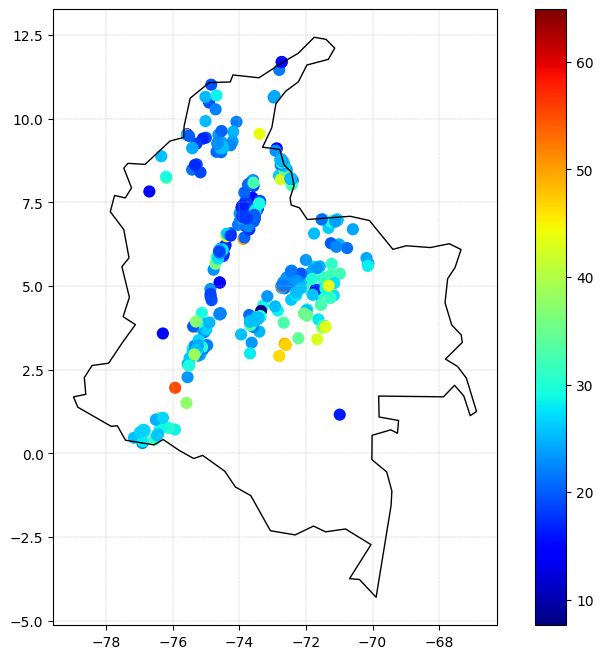

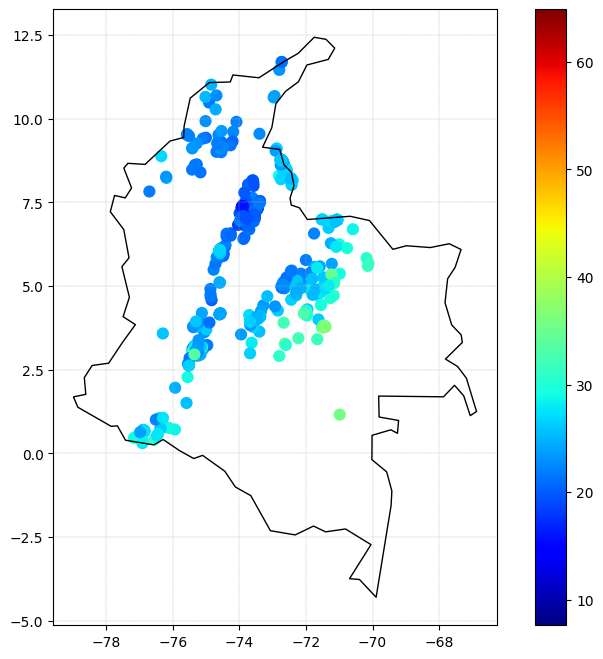

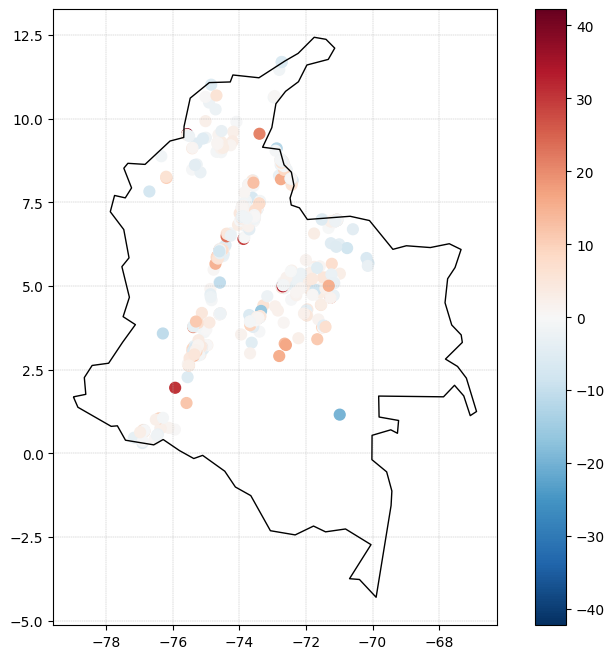

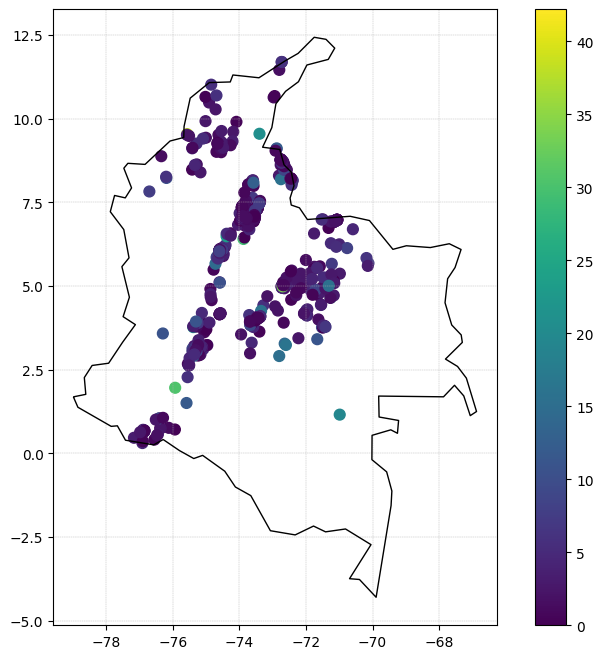

In [ ]:
# Cell 15: Mapas espaciales para test


# DataFrame con valores reales
df_pred = pd.DataFrame({
    "ID": ids,
    "actual_real": test_targs_real,
    "pred_real": test_preds_real
})

# GeoDataFrame actual
actual_data = test_df.copy()
actual_data['ID'] = actual_data['ID'].astype(int)
df_pred['ID'] = df_pred['ID'].astype(int)

actual_gdf = gpd.GeoDataFrame(
    actual_data.merge(df_pred[['ID','actual_real','pred_real']], on='ID'),
    geometry=gpd.points_from_xy(
        actual_data['Longitude'],
        actual_data['Latitude']
    ),
    crs="EPSG:4326"
).dropna(subset=['geometry'])

# Predicho
predicted_gdf = actual_gdf.copy()

# Diferencias
actual_col = "actual_real"
pred_col   = "pred_real"

actual_gdf["diff"] = actual_gdf[actual_col] - actual_gdf[pred_col]
actual_gdf["abs_diff"] = np.abs(actual_gdf["diff"])

merged = actual_gdf  # simplificación

# Rangos de colores coherentes
vmin = min(merged[actual_col].min(), merged[pred_col].min())
vmax = max(merged[actual_col].max(), merged[pred_col].max())

vabs = np.nanmax(np.abs(merged["diff"]))
vabs_abs = merged["abs_diff"].max()

# Mapa base Colombia
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

possible_cols = ['iso_a3', 'ISO_A3', 'ADM0_A3', 'SOV_A3']
code_col = next(c for c in possible_cols if c in world.columns)

colombia = world[world[code_col] == 'COL']

minx, miny, maxx, maxy = colombia.total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05
bbox = (minx - padx, maxx + padx, miny - pady, maxy + pady)

def base_map(ax):
    colombia.boundary.plot(ax=ax, linewidth=1.0, color='black')
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    ax.set_aspect('auto')
    ax.grid(True, linestyle='--', linewidth=0.3)

# Mapa actual
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column=actual_col, cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_actual_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Mapa predicho
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column=pred_col, cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_predicted_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Mapa diferencia
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="diff", cmap='RdBu_r',
    markersize=60, legend=True, vmin=-vabs, vmax=vabs
)
fig.savefig("map_difference_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Mapa diferencia absoluta
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="abs_diff", cmap='viridis',
    markersize=60, legend=True, vmin=0, vmax=vabs_abs
)
fig.savefig("map_abs_difference_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()


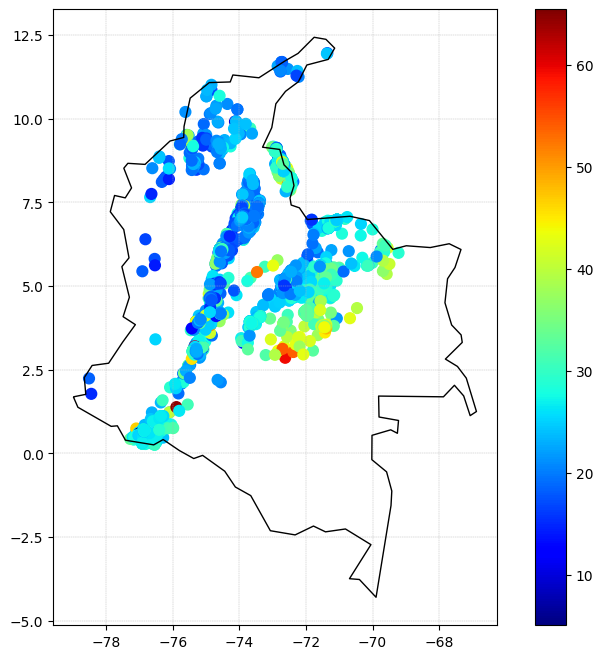

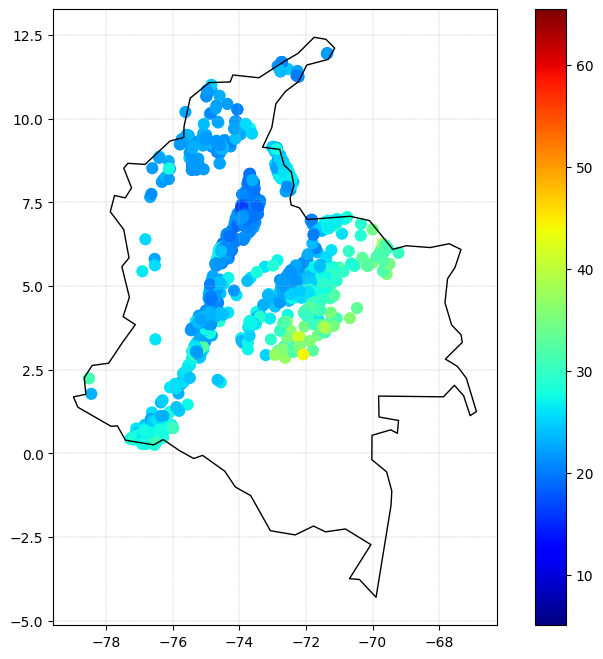

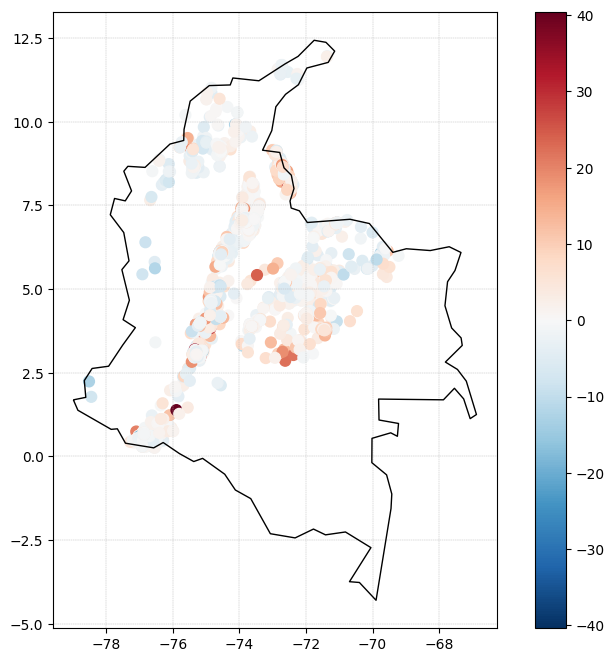

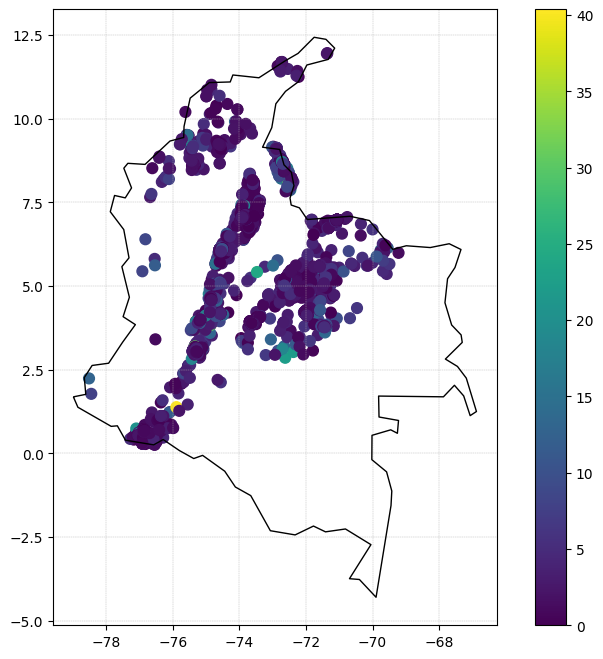

In [ ]:
# Cell 16: Mapas espaciales en entrenamiento

# DataFrame con valores reales
df_pred_train = pd.DataFrame({
    "ID": ids_train,
    "actual_real": train_targs_real,
    "pred_real": train_preds_real
})

df_pred_train['ID'] = df_pred_train['ID'].astype(int)

# GeoDataFrame base con coordenadas
actual_data = train_df.copy()
actual_data['ID'] = actual_data['ID'].astype(int)

merged = actual_data.merge(df_pred_train, on='ID')

merged = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(
        merged['Longitude'],
        merged['Latitude']
    ),
    crs="EPSG:4326"
).dropna(subset=['geometry'])

# Diferencias
merged["diff"] = merged["actual_real"] - merged["pred_real"]
merged["abs_diff"] = np.abs(merged["diff"])

# Rangos color consistentes
vmin = min(merged["actual_real"].min(), merged["pred_real"].min())
vmax = max(merged["actual_real"].max(), merged["pred_real"].max())

vabs = np.nanmax(np.abs(merged["diff"]))
vabs_abs = merged["abs_diff"].max()

# Base Colombia
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

possible_cols = ['iso_a3', 'ISO_A3', 'ADM0_A3', 'SOV_A3']
code_col = next(c for c in possible_cols if c in world.columns)

colombia = world[world[code_col] == 'COL']

minx, miny, maxx, maxy = colombia.total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05
bbox = (minx - padx, maxx + padx, miny - pady, maxy + pady)

def base_map(ax):
    colombia.boundary.plot(ax=ax, linewidth=1.0, color='black')
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    ax.set_aspect('auto')
    ax.grid(True, linestyle='--', linewidth=0.3)

# Actual
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="actual_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_actual_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Predicho
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="pred_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_predicted_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="diff", cmap='RdBu_r',
    markersize=60, legend=True, vmin=-vabs, vmax=vabs
)
fig.savefig("map_difference_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia absoluta
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="abs_diff", cmap='viridis',
    markersize=60, legend=True, vmin=0, vmax=vabs_abs
)
fig.savefig("map_abs_difference_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()


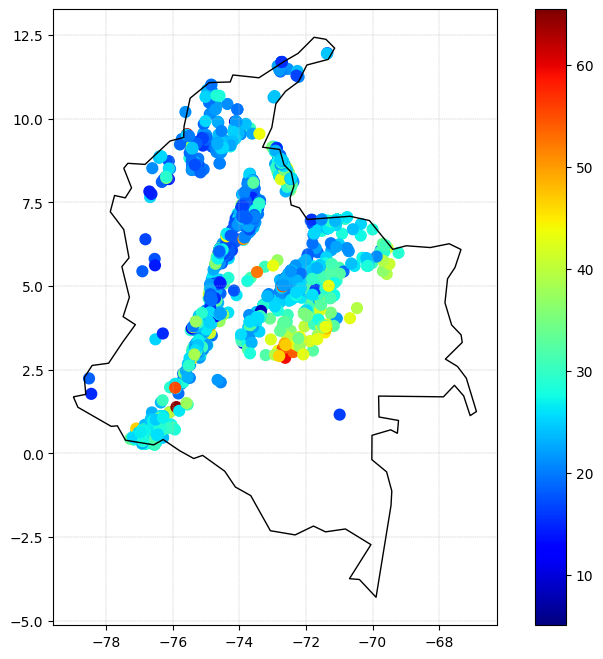

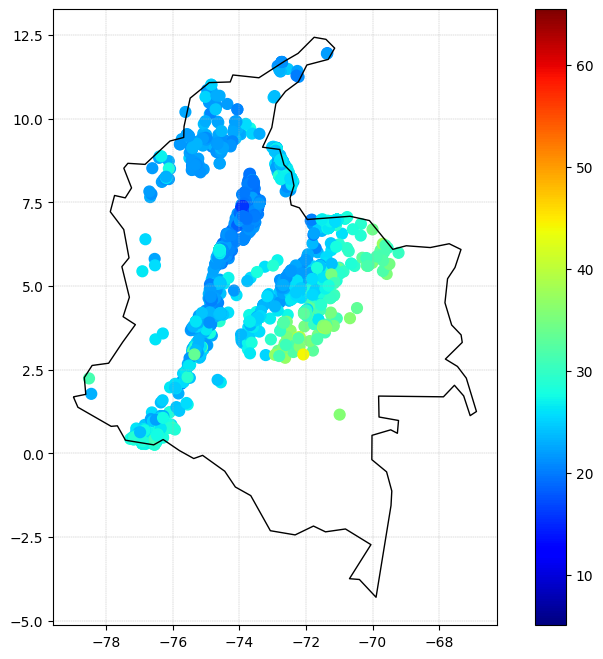

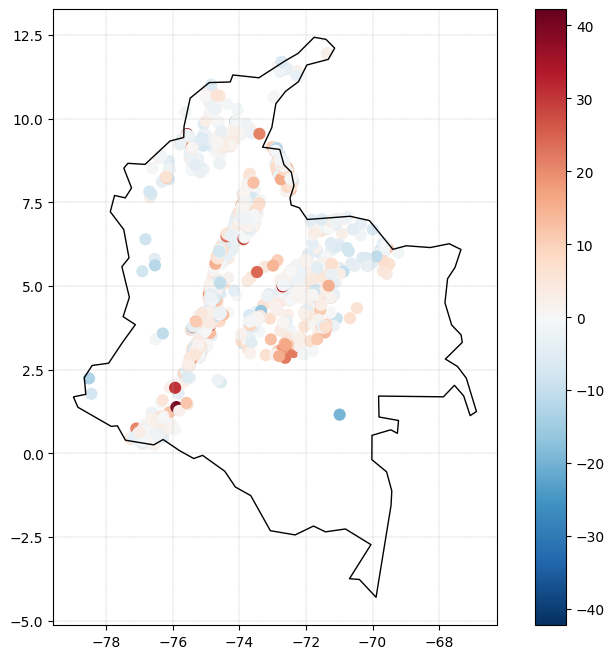

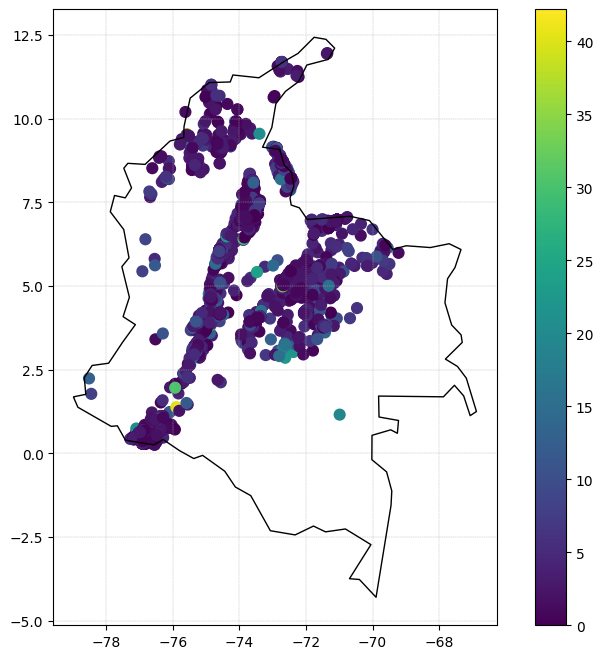

In [ ]:
# Cell 17: Mapas espaciales todo el conjunto de datos

# Combinar datasets originales
full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df["ID"] = full_df["ID"].astype(int)

# Combinar predicciones
df_pred_all = pd.concat(
    [
        df_pred_train[["ID", "actual_real", "pred_real"]],
        df_pred[["ID", "actual_real", "pred_real"]]
    ],
    ignore_index=True
)

df_pred_all["ID"] = df_pred_all["ID"].astype(int)

# Merge coords + valores reales
merged = full_df.merge(df_pred_all, on="ID")

merged = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(
        merged['Longitude'],
        merged['Latitude']
    ),
    crs="EPSG:4326"
).dropna(subset=['geometry'])

# Diferencias
merged["diff"] = merged["actual_real"] - merged["pred_real"]
merged["abs_diff"] = np.abs(merged["diff"])

# Rangos color coherentes
vmin = min(merged["actual_real"].min(), merged["pred_real"].min())
vmax = max(merged["actual_real"].max(), merged["pred_real"].max())

vabs = np.nanmax(np.abs(merged["diff"]))
vabs_abs = merged["abs_diff"].max()

# Base Colombia
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

possible_cols = ['iso_a3', 'ISO_A3', 'ADM0_A3', 'SOV_A3']
code_col = next(c for c in possible_cols if c in world.columns)

colombia = world[world[code_col] == 'COL']

minx, miny, maxx, maxy = colombia.total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05
bbox = (minx - padx, maxx + padx, miny - pady, maxy + pady)

def base_map(ax):
    colombia.boundary.plot(ax=ax, linewidth=1.0, color='black')
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    ax.set_aspect('auto')
    ax.grid(True, linestyle='--', linewidth=0.3)

# Actual
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="actual_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_actual_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Predicho
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="pred_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_predicted_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="diff", cmap='RdBu_r',
    markersize=60, legend=True, vmin=-vabs, vmax=vabs
)
fig.savefig("map_difference_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia absoluta
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="abs_diff", cmap='viridis',
    markersize=60, legend=True, vmin=0, vmax=vabs_abs
)
fig.savefig("map_abs_difference_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

TEST REAL -> RMSE=5.228, MAE=3.095, R2=0.300


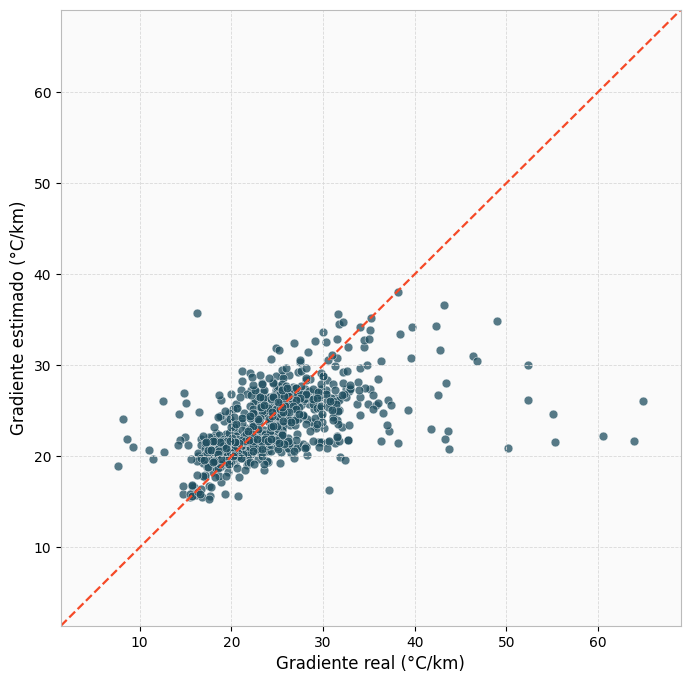

TRAIN REAL -> RMSE=4.536, MAE=2.747, R2=0.425


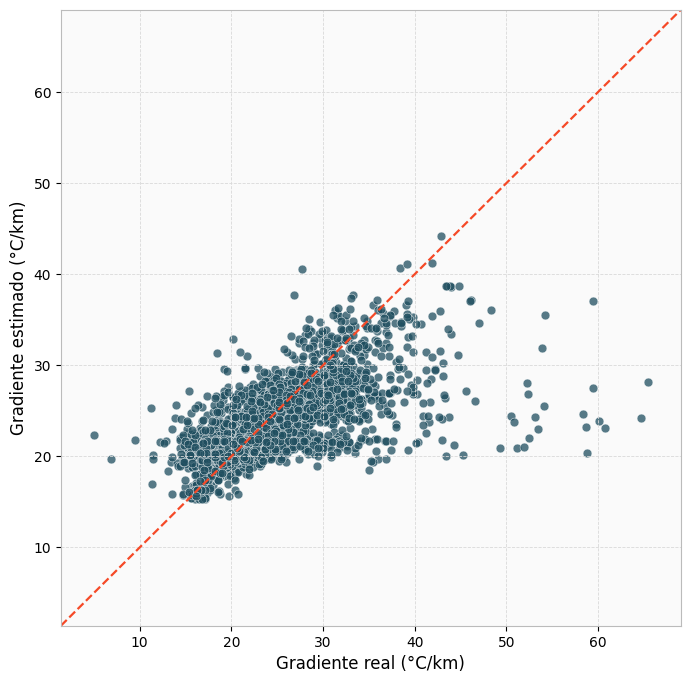

FULL REAL -> RMSE=4.682, MAE=2.817, R2=0.398


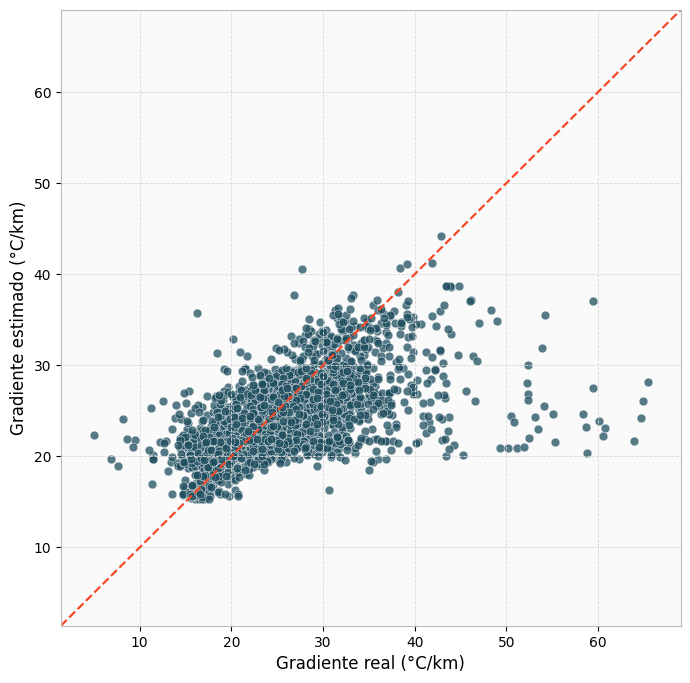

In [ ]:
# Cell 18: relación real vs predicho

# Arrays
tp = np.ravel(train_preds_real)
tt = np.ravel(train_targs_real)

ep = np.ravel(test_preds_real)
et = np.ravel(test_targs_real)

full_preds = np.concatenate([tp, ep])
full_targs = np.concatenate([tt, et])

datasets = {
    "TEST": (ep, et),
    "TRAIN": (tp, tt),
    "FULL": (full_preds, full_targs)
}

# Rangos comunes ejes
all_vals = np.concatenate([tp, tt, ep, et])
xmin = np.nanmin(all_vals)
xmax = np.nanmax(all_vals)

pad = (xmax - xmin) * 0.06 if (xmax - xmin) > 0 else 0.5
xlim = (xmin - pad, xmax + pad)
ylim = (xmin - pad, xmax + pad)

# Colores elegantes
point_color = "#1f4e5f"   # azul petróleo
line_color  = "#F54927"   # línea referencia
grid_color  = "#d9d9d9"

# Graficar
for name, (preds, targs) in datasets.items():

    preds = np.ravel(preds)
    targs = np.ravel(targs)

    rmse = np.sqrt(mean_squared_error(targs, preds))
    mae  = mean_absolute_error(targs, preds)
    r2   = r2_score(targs, preds) if len(targs) > 1 else np.nan

    fig, ax = plt.subplots(figsize=(8,8))

    ax.set_facecolor("#fafafa")

    ax.scatter(
        targs, preds,
        s=40,
        alpha=0.75,
        color=point_color,
        edgecolor="white",
        linewidth=0.4
    )

    ax.plot(
        [xlim[0], xlim[1]],
        [xlim[0], xlim[1]],
        linestyle="--",
        color=line_color,
        linewidth=1.6
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_xlabel("Gradiente real (°C/km)", fontsize=12)
    ax.set_ylabel("Gradiente estimado (°C/km)", fontsize=12)

    ax.grid(True, linestyle="--", linewidth=0.6, color=grid_color)

    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(0.8)

    fname = f"real_vs_estimado_{name.lower()}_REAL.pdf"
    fig.savefig(fname, dpi=300, bbox_inches='tight')

    print(
        f"{name} REAL -> RMSE={rmse:.3f}, "
        f"MAE={mae:.3f}, R2={r2:.3f}"
    )

    plt.show()

In [ ]:
!zip -j best_full.zip /content/run_resnet50_attention/best_full.pth
from google.colab import files
files.download("best_full.zip")


  adding: best_full.pth (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -j best_head.zip /content/run_resnet50_attention/best_head.pth
from google.colab import files
files.download("best_head.zip")


  adding: best_head.pth (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -j best_backbone.zip /content/run_resnet50_attention/best_backbone.pth
from google.colab import files
files.download("best_backbone.zip")

  adding: best_backbone.pth (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>